# **Import Libraries**

In [ ]:
# ── STEP 1 — Imports ──────────────────────────────────────
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Run this ONCE at the top of notebook
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Air-Draw'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load data sets**

In [ ]:
# ── STEP 2 — Define Transform + Load Data ─────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False,
                                download=True, transform=transform)


In [ ]:
# ── STEP 3 — Create DataLoaders ───────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)


# **Visualize data set**

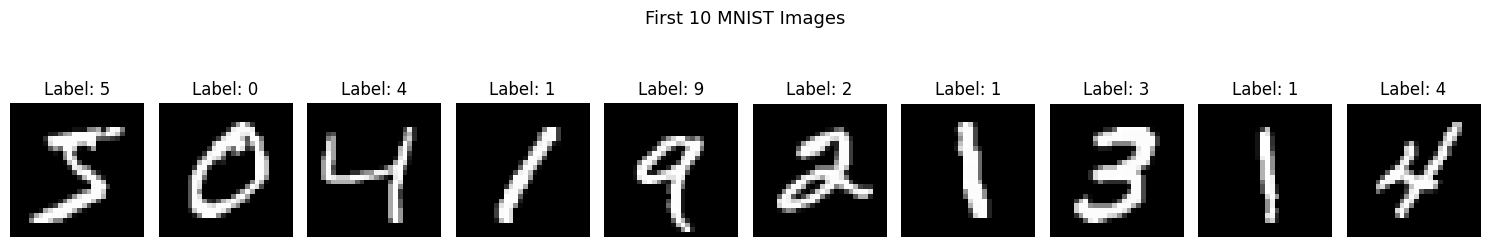

In [ ]:
# ── STEP 4 — Visualize Data ───────────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.suptitle('First 10 MNIST Images', fontsize=13)
plt.tight_layout()
plt.show()

# **BUilding the model**

In [ ]:
# ── STEP 5 — Build CNN ────────────────────────────────────
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


# **Training loops**

In [ ]:
# ── STEP 6 — Training Loop ────────────────────────────────
model     = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}/10 completed - Loss: {loss.item():.4f}')

Epoch 1/10 completed - Loss: 0.0362
Epoch 2/10 completed - Loss: 0.2475
Epoch 3/10 completed - Loss: 0.2730
Epoch 4/10 completed - Loss: 0.0025
Epoch 5/10 completed - Loss: 0.0010
Epoch 6/10 completed - Loss: 0.0808
Epoch 7/10 completed - Loss: 0.0030
Epoch 8/10 completed - Loss: 0.1604
Epoch 9/10 completed - Loss: 0.0005
Epoch 10/10 completed - Loss: 0.0009


# **Model Saved**

In [ ]:
# Step 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2 — Create folder in Drive
import os
os.makedirs('/content/drive/MyDrive/Air-Draw/model', exist_ok=True)

# Step 3 — Save model there
torch.save(model.state_dict(),
           '/content/drive/MyDrive/Air-Draw/model/airdraw_model.pth')
print("Model saved to Google Drive successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive successfully!


# **Plotting curves**

In [ ]:
train_losses = []    # add this before loop

for epoch in range(10):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()    # accumulate loss

    epoch_loss = running_loss / len(train_loader)    # average loss
    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/10 completed - Loss: {epoch_loss:.4f}')


Epoch 1/10 completed - Loss: 0.0041
Epoch 2/10 completed - Loss: 0.0031
Epoch 3/10 completed - Loss: 0.0018
Epoch 4/10 completed - Loss: 0.0049
Epoch 5/10 completed - Loss: 0.0018
Epoch 6/10 completed - Loss: 0.0014
Epoch 7/10 completed - Loss: 0.0067
Epoch 8/10 completed - Loss: 0.0025
Epoch 9/10 completed - Loss: 0.0019
Epoch 10/10 completed - Loss: 0.0031


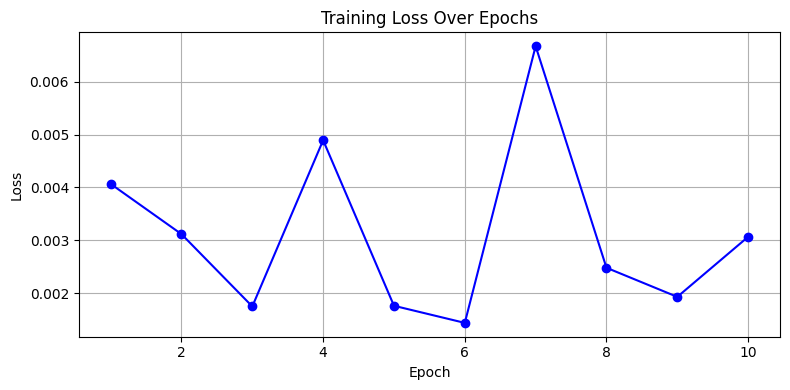

In [ ]:
# Model save
import os
os.makedirs(f'{BASE_PATH}/model', exist_ok=True)
os.makedirs(f'{BASE_PATH}/results', exist_ok=True)
# Plot after training
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), train_losses, marker='o', color='blue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/results/accuracy_plot.png')
plt.show()

# **Model Evaluation**

In [ ]:
model.eval()    # switch to evaluation mode

correct = 0
total = 0

with torch.no_grad():    # no gradient calculation needed
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 98.81%


# **Confusion Matrix**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.97      0.99      0.98       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



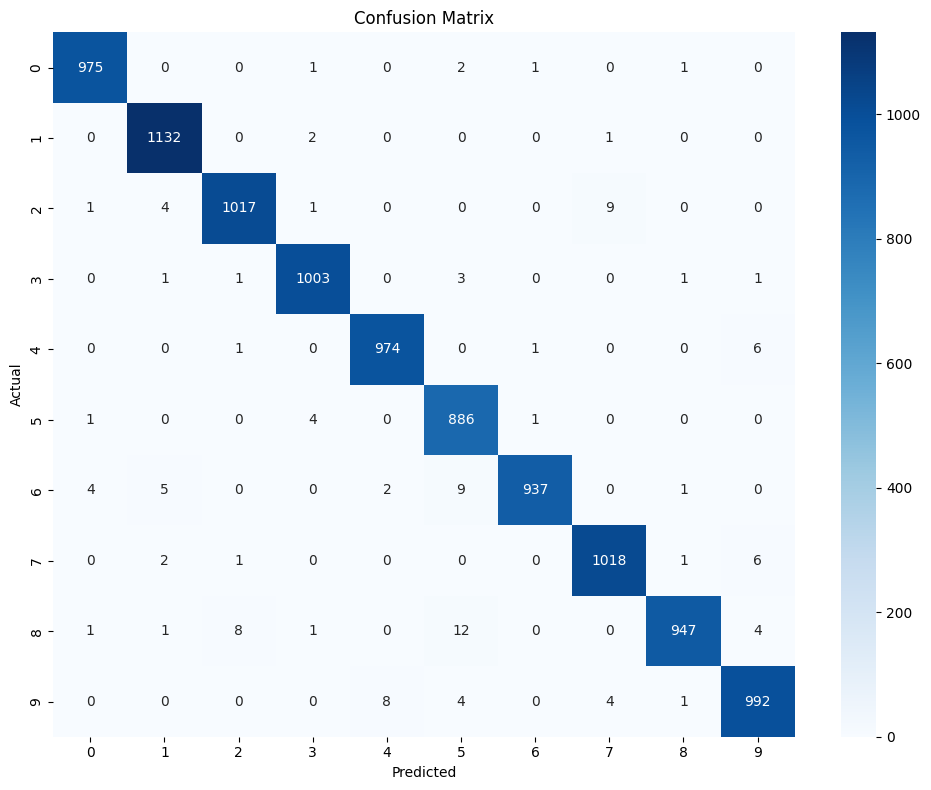

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_predictions = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Precision Recall F1
print(classification_report(all_labels, all_predictions,
      target_names=[str(i) for i in range(10)]))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/results/confusion_matrix.png')
plt.show()